<a href="https://colab.research.google.com/github/ridhoain/personal/blob/main/road_travel_time.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
reading = (-0.9721, 51.4543)  # Reading Station
jakarta = (106.8272, -6.1754)  # Monas


In [3]:
!pip install openrouteservice

In [5]:
import openrouteservice
client = openrouteservice.Client(key='eyJvcmciOiI1YjNjZTM1OTc4NTExMTAwMDFjZjYyNDgiLCJpZCI6IjY0MDBlMGM3ZTczNzQ1ZDM5OWM3YzkwM2VlNDE3M2ZjIiwiaCI6Im11cm11cjY0In0=')

iso_reading = client.isochrones(
    locations=[reading],
    profile='driving-car',
    range=[3600]  # 1 hour
)

iso_jakarta = client.isochrones(
    locations=[jakarta],
    profile='driving-car',
    range=[3600]
)


In [6]:
import json
with open('reading_1hour.geojson', 'w') as f:
    json.dump(iso_reading, f)
with open('jakarta_1hour.geojson', 'w') as f:
    json.dump(iso_jakarta, f)


In [8]:
from shapely.geometry import shape
import geopandas as gpd

# Convert the GeoJSON feature to a GeoDataFrame
gdf_reading = gpd.GeoDataFrame.from_features(iso_reading['features'], crs="EPSG:4326")
gdf_jakarta = gpd.GeoDataFrame.from_features(iso_jakarta['features'], crs="EPSG:4326")

# Reproject to a metric CRS (UTM or Web Mercator)
gdf_reading = gdf_reading.to_crs(epsg=3857)
gdf_jakarta = gdf_jakarta.to_crs(epsg=3857)

# Compute area in square km
reading_area = gdf_reading.geometry.area.iloc[0] / 1e6
jakarta_area = gdf_jakarta.geometry.area.iloc[0] / 1e6

print(f"Reading reachable area: {reading_area:.1f} km², Jakarta: {jakarta_area:.1f} km²")


Reading reachable area: 19109.8 km², Jakarta: 5238.3 km²


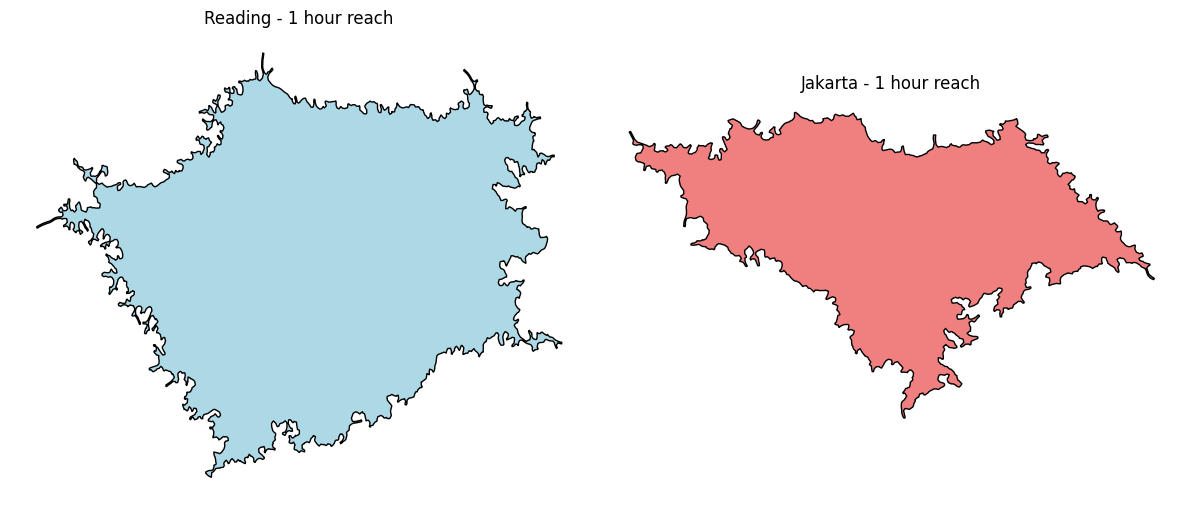

In [9]:
import matplotlib.pyplot as plt
import geopandas as gpd

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

gdf_reading.plot(ax=ax[0], color='lightblue', edgecolor='black')
ax[0].set_title("Reading - 1 hour reach")
gdf_jakarta.plot(ax=ax[1], color='lightcoral', edgecolor='black')
ax[1].set_title("Jakarta - 1 hour reach")

for a in ax:
    a.set_axis_off()

plt.tight_layout()
plt.show()


In [ ]:
import osmnx as ox
import geopandas as gpd
import folium

# Get roads within Jakarta 1-hour isochrone polygon
polygon = gpd.GeoDataFrame.from_features(iso_jakarta['features'], crs="EPSG:4326").geometry[0]
roads = ox.graph_from_polygon(polygon, network_type='drive')
roads_gdf = ox.graph_to_gdfs(roads, nodes=False)

# Create base map
center = [polygon.centroid.y, polygon.centroid.x]
m = folium.Map(location=center, zoom_start=11, tiles="CartoDB positron")

# Add the isochrone area
folium.GeoJson(
    iso_jakarta,
    name="Jakarta 1hr",
    style_function=lambda x: {"color": "red", "fillOpacity": 0.15}
).add_to(m)

# Add roads
folium.GeoJson(
    roads_gdf,
    name="Road network",
    style_function=lambda x: {"color": "black", "weight": 1, "opacity": 0.6}
).add_to(m)

folium.LayerControl().add_to(m)
m
